<a href="https://colab.research.google.com/github/SirTEdgar/Aviation-Assignment/blob/main/Summartive_lab_Evaluating_Customer_Behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Business Understanding and data loading and inspection

Business Understanding and dateset loading and inspection

Business Scenario

The retail company operates stores in three different locations: City Center, Suburb, and Rural.
The company wants to understand whether customer behavior differs depending on where the store is located.
The analysis focuses on customer spending, satisfaction, product preferences, and promotional purchases.

Business Questions.

Qn.1 Do customer spending patterns, satisfaction levels, and product preferences differ significantly across City Center, Suburb, and Rural store locations?

Qn.2 Do promotional periods result in significantly higher customer spending compared with non-promotional periods?

How the Analysis Can Guide Marketing and Operational Strategies






1. Marketing: If promotional periods significantly increase spending, the company could invest more in promotions. If certain product categories are more popular in specific locations, marketing campaigns can be tailored to those customers.
2. Inventory: If product preferences differ by location, stores can stock more of the products that customers in each area prefer.
Staffing: If spending or customer activity is substantially higher in one location, the company could allocate more staff during busy periods.







**Hypotheses**

**Business Question 1:** Do promotional periods increase customer spending?

Null hypothesis (H₀):
There is no significant difference in mean customer spending between promotional and non-promotional periods.

Alternative hypothesis (H₁):
There is a significant difference in mean customer spending between promotional and non-promotional periods.

Business objective: Determine whether promotional campaigns are effective enough to justify continued or increased investment.

**Business Question 2:**

Do product preferences differ across store locations?

Null hypothesis (H₀):
Product category preference is independent of store location.

Alternative hypothesis (H₁):
Product category preference is associated with store location.

Business objective: Determine whether inventory and marketing strategies should be tailored to individual store locations.

Data types and tests

| Analysis                 | Data                                   | Groups                       | Test                   |
| ------------------------ | -------------------------------------- | ---------------------------- | ---------------------- |
| Spending by location     | Amount Spent = numerical               | City Center, Suburb, Rural   | **One-way ANOVA**      |
| Satisfaction by location | Satisfaction Rating = numerical/rating | City Center, Suburb, Rural   | **One-way ANOVA**      |
| Promotional spending     | Amount Spent = numerical               | Promotional, Non-Promotional | **Independent t-test** |

Why?

1. ANOVA is appropriate when comparing a numerical outcome across 3 groups.

2. t-test is appropriate when comparing a numerical outcome across 2 groups.


Load dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_store_customer_data.csv to retail_store_customer_data.csv


In [ ]:
df.shape

(1500, 5)

In [ ]:
import pandas as pd

df = pd.read_csv('retail_store_customer_data.csv')

df.head()

,Store_Location,Customer_Satisfaction,Product_Category,Purchase_Type,Amount_Spent
0,Rural,5.6,Groceries,Non-Promotional,40.45
1,City Center,9.7,Clothing,Promotional,53.20
2,Rural,4.4,Electronics,Non-Promotional,42.77
3,Rural,4.2,Clothing,Promotional,42.08
4,City Center,9.3,Clothing,Non-Promotional,84.25


In [ ]:
df.describe()

,Customer_Satisfaction,Amount_Spent
count,1500.00000,1500.000000
mean,6.99520,59.915973
std,1.65286,19.551829
min,1.00000,15.550000
25%,5.80000,44.170000
50%,7.00000,58.015000
75%,8.20000,72.582500
max,10.00000,128.130000


In [ ]:
df.columns

Index(['Store_Location', 'Customer_Satisfaction', 'Product_Category',
       'Purchase_Type', 'Amount_Spent'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   object 
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   object 
 3   Purchase_Type          1500 non-null   object 
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), object(3)
memory usage: 58.7+ KB


In [ ]:
df.isnull().sum()

,0
Store_Location,0
Customer_Satisfaction,0
Product_Category,0
Purchase_Type,0
Amount_Spent,0


The dataset has no missing values

In [ ]:
df['Store_Location'].value_counts()

,count
Store_Location,
City Center,520
Suburb,492
Rural,488


The store distribution is fairly equal among all locations

In [ ]:
df['Purchase_Type'].value_counts()

,count
Purchase_Type,
Promotional,888
Non-Promotional,612


Promotional purchases are more enticing yeah

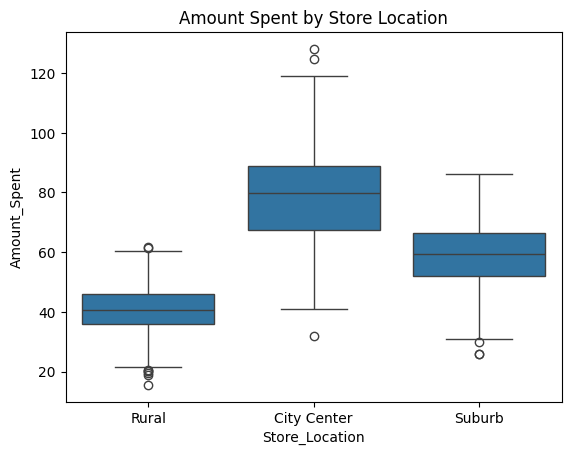

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='Store_Location', y='Amount_Spent')
plt.title('Amount Spent by Store Location')
plt.show()

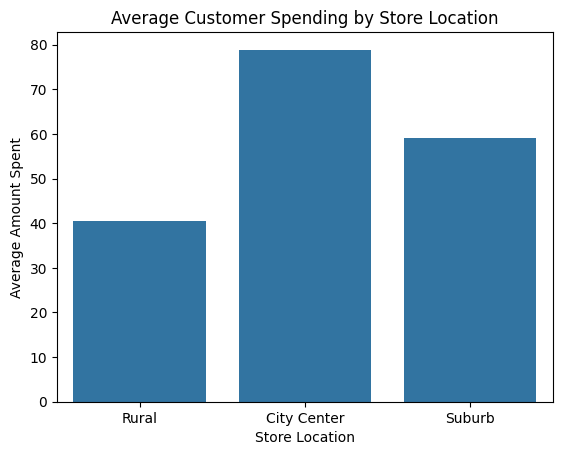

In [ ]:
sns.barplot(data=df, x='Store_Location', y='Amount_Spent', errorbar=None)

plt.title('Average Customer Spending by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Average Amount Spent')
plt.show()

Some visualizations

In [ ]:
df.columns


Index(['Store_Location', 'Customer_Satisfaction', 'Product_Category',
       'Purchase_Type', 'Amount_Spent'],
      dtype='object')

In [ ]:
df.shape

(1500, 5)

**Dataset Adequacy.**

The dataset was assessed by examining its size, variable types, missing values, group sizes and descriptive statistics.

 The number of observations in each store location was checked to ensure that the data is suitable for ANOVA, while promotional and non-promotional group sizes were checked for the t-test.

 Numerical variables were also examined using descriptive statistics and boxplots to identify unusual values. These checks help determine whether the dataset is adequate for reliable statistical analysis.

**Statistical tests**

**Test 1.**

 Spending across store locations — One-Way ANOVA

**Hypotheses**

(Null hypothesis)H₀.

 There is no significant difference in mean spending among City Center, Suburb, and Rural stores.

(Alternative hypothesis)H₁.

 At least one location has a significantly different mean spending.

In [ ]:
city_center = df[df['Store_Location'] == 'City Center']['Amount_Spent']
suburb = df[df['Store_Location'] == 'Suburb']['Amount_Spent']
rural = df[df['Store_Location'] == 'Rural']['Amount_Spent']

Create groups of each store loaction

In [ ]:
from scipy import stats

f_stat, p_value = stats.f_oneway(city_center, suburb, rural)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1386.970461564439
p-value: 0.0


Since the p-value (approximately 0) is less than 0.05, we reject the null hypothesis.

There is a statistically significant difference in customer spending across City Center, Suburb, and Rural store locations.

In [24]:
df.groupby('Store_Location')['Amount_Spent'].agg(['count', 'mean', 'std'])

,count,mean,std
Store_Location,,,
City Center,520,78.891000,15.374358
Rural,488,40.463094,7.783718
Suburb,492,59.155793,9.956044


In [ ]:
df.columns.tolist()

['Store_Location',
 'Customer_Satisfaction',
 'Product_Category',
 'Purchase_Type',
 'Amount_Spent']

In [ ]:
from scipy import stats

city_sat = df[df['Store_Location'] == 'City Center']['Customer_Satisfaction']
suburb_sat = df[df['Store_Location'] == 'Suburb']['Customer_Satisfaction']
rural_sat = df[df['Store_Location'] == 'Rural']['Customer_Satisfaction']

f_sat, p_sat = stats.f_oneway(
    city_sat,
    suburb_sat,
    rural_sat
)

print("F-statistic:", f_sat)
print("p-value:", p_sat)

F-statistic: 242.1725372118477
p-value: 7.56602972594256e-92


**Business Question 2:**

Do product preferences differ across store locations?

In [ ]:
df.groupby('Store_Location')['Customer_Satisfaction'].agg(['count', 'mean', 'std'])

,count,mean,std
Store_Location,,,
City Center,520,7.954038,1.367875
Rural,488,5.960041,1.499768
Suburb,492,7.008537,1.446679


A one-way ANOVA was conducted to determine whether customer satisfaction differed across City Center, Suburb, and Rural stores.

The test produced:

F-statistic of 242.17

p-value: 7.56602972594256e-92.

 Since the p-value is less than 0.05, the null hypothesis is rejected.

  Therefore, there is a statistically significant difference in customer satisfaction across the three store locations.

City Center had the highest average satisfaction rating (7.95), followed by Suburb (7.01), while Rural had the lowest average satisfaction (5.96).

This suggests that the company should investigate why satisfaction is considerably lower in Rural stores and consider targeted improvements to the customer experience in those locations.

QN.3 Do promotional periods result in significantly higher customer spending compared with non-promotional periods?

In [32]:
promotional = df[df['Purchase_Type'] == 'Promotional']['Amount_Spent']

non_promotional = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']

The dataset was divided into two independent groups based on purchase type: promotional and non-promotional purchases.

In [33]:
print("Promotional customers:", len(promotional))
print("Non-promotional customers:", len(non_promotional))

print("Promotional mean:", promotional.mean())
print("Non-promotional mean:", non_promotional.mean())

Promotional customers: 888
Non-promotional customers: 612
Promotional mean: 60.01853603603603
Non-promotional mean: 59.7671568627451


In [34]:
t_stat, p_value_t = stats.ttest_ind(
    promotional,
    non_promotional,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value_t)

t-statistic: 0.24371392195351743
p-value: 0.8074909679541247


In [35]:
difference = promotional.mean() - non_promotional.mean()

print("Difference in mean spending:", difference)

Difference in mean spending: 0.2513791732909354


Cohen Ds

In [36]:
import numpy as np

n1 = len(promotional)
n2 = len(non_promotional)

pooled_std = np.sqrt(
    ((n1 - 1) * promotional.std()**2 +
     (n2 - 1) * non_promotional.std()**2)
    / (n1 + n2 - 2)
)

cohens_d = difference / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.012853034515105187


In [37]:
print("Promotional mean:", promotional.mean())
print("Non-promotional mean:", non_promotional.mean())
print("Difference:", promotional.mean() - non_promotional.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value_t)
print("Cohen's d:", cohens_d)

Promotional mean: 60.01853603603603
Non-promotional mean: 59.7671568627451
Difference: 0.2513791732909354
t-statistic: 0.24371392195351743
p-value: 0.8074909679541247
Cohen's d: 0.012853034515105187


A Cohen's d of 0.0129 means the difference in average spending between promotional and non-promotional purchases is extremely small in practical terms.

An independent t-test was conducted to compare customer spending between promotional and non-promotional purchases.

The test produced:
t-statistic of 0.244

p-value of 0.8075.

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

 Therefore, there is insufficient statistical evidence to conclude that promotional periods result in significantly different customer spending.

Interpretation and recommendations

  Qn 1.Spending across store locations

Key finding: City Center customers spend approximately $38.43 more than Rural customers.

The differences also exceed the assignment's $10 minimum detectable effect.

This makes the differences practically important, not just statistically significant.

Business implication: The company should consider allocating resources according to location.

City Center may require more inventory and staffing because of higher spending, while Rural stores may need targeted strategies to increase customer spending.

**Qn 2. Customer Satisfaction Across Store Locations**

The second ANOVA also showed a statistically significant difference:

F-statistic = 242.17
p-value = 7.57 × 10⁻⁹²

Since p < 0.05, we reject the null hypothesis.

**Key finding**: Rural stores have the lowest average satisfaction (5.96), compared with 7.95 in City Center.

**Business implication**: Management should investigate why Rural customers report lower satisfaction.

Possible areas to investigate include staffing, product availability, waiting times, and customer service.

Recommendation:

Allocate more inventory and staffing to higher-spending locations.





Investigate why Rural spending is lower.

Develop targeted marketing campaigns for Rural customers rather than applying the exact same strategy everywhere.

Consider local promotions or product bundles designed around Rural customer preferences.

In [25]:
product_location = pd.crosstab(
    df['Store_Location'],
    df['Product_Category']
)

print(product_location)

Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center            156          191        173
Rural                  137          199        152
Suburb                 160          193        139


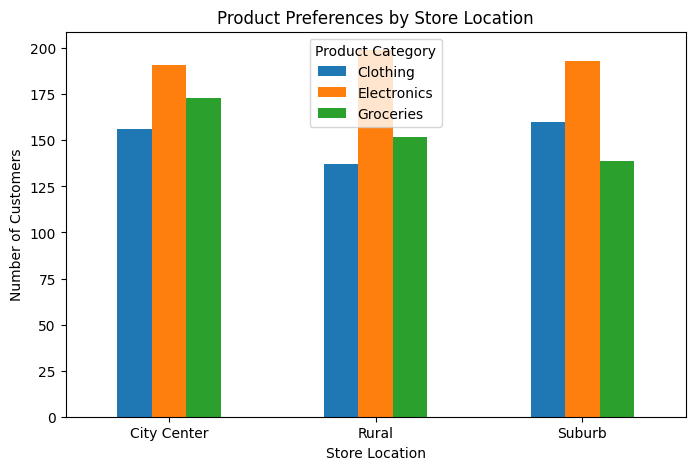

In [26]:
product_location.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Product Preferences by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.show()

Viz 1. Bar chart

Bar chart viz showing product preference in all three locations. (Multivariate analysis)

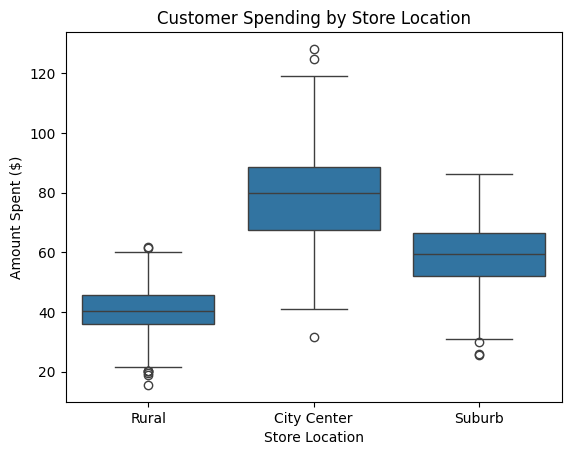

In [27]:
sns.boxplot(
    data=df,
    x='Store_Location',
    y='Amount_Spent'
)

plt.title('Customer Spending by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Amount Spent ($)')
plt.show()

Viz 2: Box plot

This viz shows both the distribution and outliers.



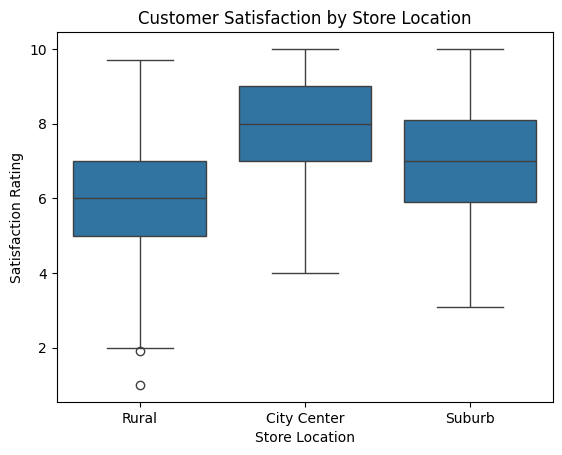

In [30]:
sns.boxplot(
    data=df,
    x='Store_Location',
    y='Customer_Satisfaction'
)

plt.title('Customer Satisfaction by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Satisfaction Rating')
plt.show()

Viz 3: Box plot

Showing consumer preferences

**Conclusion**

This analysis demonstrated the importance of experimental design and appropriate statistical test selection when evaluating customer behavior.

One-way ANOVA was appropriate for comparing spending and satisfaction across three store locations.

An independent t-test was appropriate for comparing spending between promotional and non-promotional purchases.

The large sample size of 1,500 observations provided sufficient data for the analyses.

The relatively balanced store-location groups also strengthened the comparison between locations.

The $10 minimum detectable effect was useful for distinguishing statistically significant differences from differences that were large enough to matter to the business.

The analysis found significant differences in both customer spending and satisfaction across store locations.

City Center customers had the highest average spending and satisfaction, while Rural customers had the lowest.

In contrast, promotional and non-promotional purchases showed almost identical average spending.

The t-test produced a p-value of 0.8075, while Cohen's d was only 0.0129, indicating a negligible effect.

**Limitations**

One limitation is that the dataset does not contain information about factors that could influence spending and satisfaction, such as customer income, age, household size, visit frequency, waiting time, staffing levels, or specific promotional discounts.

Another limitation is that the data appears observational rather than being generated from a randomized experiment. Therefore, the analysis can identify associations and differences but cannot establish that store location or promotions directly caused the observed outcomes.

Product preferences were also analyzed descriptively rather than through a formal test of association.

Future improvements:
Future analyses could collect customer:
1. demographics
2. transaction frequency
3. promotion type
4. discount percentage
5. profit margin
6. waiting time
7. inventory availability

A randomized promotional experiment could also be conducted to determine whether promotions directly cause higher spending.